# DIPA2 Caption Generation Notebook

This notebook is the DIPA2 version of the VISPR caption-generation notebook.

Main changes from VISPR:
- Uses `DIPA2/dataset/images` and `DIPA2/dataset/annotations.csv`.
- Aggregates **multiple annotators per image** before generation.
- Keeps annotator/platform support in the prompt so labels with stronger agreement are prioritized.
- Uses DIPA2 object-level categories instead of VISPR labels, restricted to the 21 categories the accompanying paper's Appendix (Table 8) actually maps from DIPA2 onto its Visual Privacy Taxonomy: Person, Finger, Identity, Printed Material, Machine, Screen, Electronic Devices, Vehicle Plate, Clothing, Book, Table, Toy, Home Interior, Cosmetics, Musical Instrument, Accessory, Pet, Food, Place Identifier, Scenery, Photo. DIPA2's native `cigarettes` category (not in the paper's mapping) and `others` are both folded into the existing `DROP_OTHERS` filtering, matching the paper's stated exclusion of unmappable "Others" annotations.
- Processes each image once by default, using the aggregated DIPA2 annotation context.


## 1. Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Install dependencies

In [ ]:
!pip -q install -U google-genai pandas pillow matplotlib tqdm

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

folder_path = Path("/content/drive/MyDrive/DIPA2/dataset/images")  # change this path

image_exts = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}

images = [
    p for p in folder_path.rglob("*")
    if p.is_file() and p.suffix.lower() in image_exts
]

print("Number of images:", len(images))
print("First 5 images:")
for img in images[:5]:
    print(img)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Number of images: 1304
First 5 images:
/content/drive/MyDrive/DIPA2/dataset/images/43191.jpg
/content/drive/MyDrive/DIPA2/dataset/images/145597.jpg
/content/drive/MyDrive/DIPA2/dataset/images/541538.jpg
/content/drive/MyDrive/DIPA2/dataset/images/129739.jpg
/content/drive/MyDrive/DIPA2/dataset/images/211141.jpg


## 3. Paths, model, and run settings

Change `DIPA2_ROOT` only if your unzipped folder is somewhere else. The expected folder layout is `.../dataset/images`, `.../dataset/annotations.csv`, and `.../dataset/img_annotation_map.json`.

In [ ]:
from pathlib import Path
import os

# ---------------------------------------------------------------------
# DIPA2 dataset paths
# ---------------------------------------------------------------------
# Expected after unzip:
# /content/drive/MyDrive/DIPA2/dataset/images
# /content/drive/MyDrive/DIPA2/dataset/annotations.csv
# /content/drive/MyDrive/DIPA2/dataset/img_annotation_map.json

CANDIDATE_DIPA2_ROOTS = [
    Path("/content/drive/MyDrive/DIPA2/dataset"),
]

DIPA2_ROOT = next(
    (p for p in CANDIDATE_DIPA2_ROOTS if (p / "images").exists() and (p / "annotations.csv").exists()),
    CANDIDATE_DIPA2_ROOTS[0],
)

IMAGE_DIR = DIPA2_ROOT / "images"
ANNOTATIONS_CSV = DIPA2_ROOT / "annotations.csv"
IMG_ANNOTATION_MAP_JSON = DIPA2_ROOT / "img_annotation_map.json"

# ---------------------------------------------------------------------
# Output paths
# ---------------------------------------------------------------------
RUN_ROOT = Path("/content/drive/MyDrive/DIPA2/new_exps/caption_gen_dipa3")
OUTPUT_DIR = RUN_ROOT / "captions_v1"
FAILED_JSON_DIR = RUN_ROOT / "failed_jsons_v1"
REPORT_DIR = RUN_ROOT / "reports"
GRAPH_DIR = RUN_ROOT / "graphs"

STATUS_CSV_PATH = RUN_ROOT / "image_status_log.csv"
STATE_PATH = RUN_ROOT / "run_state.json"
CONTEXT_CSV_PATH = RUN_ROOT / "dipa2_image_level_context.csv"

for p in [RUN_ROOT, OUTPUT_DIR, FAILED_JSON_DIR, REPORT_DIR, GRAPH_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("DIPA2_ROOT:", DIPA2_ROOT)
print("IMAGE_DIR:", IMAGE_DIR)
print("ANNOTATIONS_CSV:", ANNOTATIONS_CSV)
print("IMG_ANNOTATION_MAP_JSON:", IMG_ANNOTATION_MAP_JSON)
print("OUTPUT_DIR:", OUTPUT_DIR)

assert IMAGE_DIR.exists(), f"Missing image folder: {IMAGE_DIR}"
assert ANNOTATIONS_CSV.exists(), f"Missing annotations.csv: {ANNOTATIONS_CSV}"

# ---------------------------------------------------------------------
# Gemini/API settings
# ---------------------------------------------------------------------
MODEL_STAGE1 = "gemini-3.1-flash-lite-preview"  # change if you want another Gemini model
TEMPERATURE_STAGE1 = 0.9

# Set MAX_IMAGES to a small number for testing, then None for full run.
MAX_IMAGES = None
SKIP_IF_JSON_EXISTS = True
SKIP_FAILED_IF_LOGGED = False

# Async settings. Increase carefully if you have quota.
TOTAL_CONCURRENCY = 4
REQUESTS_PER_KEY = 500

# ---------------------------------------------------------------------
# DIPA2 multi-annotator aggregation settings
# ---------------------------------------------------------------------
# union: include any category any annotator/object row marked privacy-threatening.
# supported: include only labels with row_support >= MIN_ROW_SUPPORT.
AGGREGATION_MODE = "union"  # "union" or "supported"
MIN_ROW_SUPPORT = 1

# If True, only include categories seen from both CrowdWorks/Japan and Prolific/UK.
# Usually False, because this can remove valid culturally specific privacy perceptions.
REQUIRE_BOTH_PLATFORMS = False

# Optional filter. None keeps all. Example: 3 keeps categories whose mean informativeness >= 3.
MIN_MEAN_INFORMATIVENESS = None

# Match VLM paper: ignore DIPA2 "others"
DROP_OTHERS = True

# Important: only run model on images that still have usable labels after dropping "others"
PROCESS_ONLY_IMAGES_WITH_CONTEXT = True

DIPA2_ROOT: /content/drive/MyDrive/DIPA2/dataset
IMAGE_DIR: /content/drive/MyDrive/DIPA2/dataset/images
ANNOTATIONS_CSV: /content/drive/MyDrive/DIPA2/dataset/annotations.csv
IMG_ANNOTATION_MAP_JSON: /content/drive/MyDrive/DIPA2/dataset/img_annotation_map.json
OUTPUT_DIR: /content/drive/MyDrive/DIPA2/new_exps/caption_gen_dipa3/captions_v1


## 4. API keys

Use Colab Secrets if possible: add a secret named `GOOGLE_API_KEY`. You can also paste multiple keys in `MANUAL_API_KEYS`.

In [ ]:
import os

MANUAL_API_KEYS = [
    "AIzaREDACTED_ROTATE_THIS_KEY",
    "AIzaREDACTED_ROTATE_THIS_KEY",
    "AIzaREDACTED_ROTATE_THIS_KEY",
    "AIzaREDACTED_ROTATE_THIS_KEY",
    "AIzaREDACTED_ROTATE_THIS_KEY",
    "AIzaREDACTED_ROTATE_THIS_KEY",
    "AIzaREDACTED_ROTATE_THIS_KEY",
    "AIzaREDACTED_ROTATE_THIS_KEY",
    "AIzaREDACTED_ROTATE_THIS_KEY",
    "AIzaREDACTED_ROTATE_THIS_KEY",
]

def get_colab_secret(name: str):
    try:
        from google.colab import userdata
        return userdata.get(name)
    except Exception:
        return None

API_KEYS = [k for k in MANUAL_API_KEYS if k and "paste_" not in k]

if not API_KEYS:
    secret_key = get_colab_secret("GOOGLE_API_KEY")
    if secret_key:
        API_KEYS = [secret_key]

if not API_KEYS and os.environ.get("GOOGLE_API_KEY"):
    API_KEYS = [os.environ["GOOGLE_API_KEY"]]

print("Number of API keys loaded:", len(API_KEYS))
if not API_KEYS:
    raise ValueError("No API key found. Add GOOGLE_API_KEY in Colab Secrets or paste keys into MANUAL_API_KEYS.")


Number of API keys loaded: 10


## 5. DIPA2 labels and privacy-category guide

In [ ]:
MERGED_DIPA2_LABEL_GUIDE = {
    # =====================================================
    # DIPA2 OBJECT-LEVEL PRIVACY LABELS
    # =====================================================
    # Note:
    # DIPA2 has object-level privacy annotations from multiple annotators.
    # This label set is restricted to the 21 categories the accompanying paper's
    # Appendix (Table 8) actually maps from DIPA2 onto the Visual Privacy Taxonomy.
    # DIPA2's native "cigarettes" category (not in that mapping) and "others" are
    # both intentionally excluded to match the paper, which states it did not
    # measure "Others" annotations because they span multiple private concepts
    # that cannot be effectively mapped onto a single category.

    "person": (
        "Use when the caption naturally refers to a visible person, recognizable individual, face/body presence, "
        "selfie, portrait, group member, bystander, or person-centered moment. The caption may reveal identity, "
        "appearance, relationship, role, routine, or social context connected to the person. Do not use merely because "
        "a person exists in the image unless the caption actually makes the person privacy-relevant."
    ),

    "place_identifier": (
        "Use when the caption reveals or emphasizes a specific place, venue, landmark, institution, neighborhood, "
        "station, campus, store, street area, building, or recognizable location cue. The location should matter to "
        "the privacy leak, not just be decorative scenery."
    ),

    "identity": (
        "Use when the caption reveals identity-related information such as a name, ID, badge, official card, personal "
        "document, certificate, account identity, or formal identification context. Keep identity details abstract and "
        "synthetic; avoid exact ID numbers or realistic full identifiers."
    ),

    "vehicle_plate": (
        "Use when a vehicle plate, car identity, vehicle ownership, parking context, driving-related identification, "
        "or plate visibility is part of the caption. The caption should not dump a full realistic plate number."
    ),

    "food": (
        "Use when food is privacy-relevant through personal routine, diet, health context, culture, religious practice, "
        "family habit, favorite place, celebration, or a recurring personal preference. Do not use for generic food "
        "unless the caption turns it into personal context."
    ),

    "printed_material": (
        "Use when printed material is visible or caption-relevant, such as forms, letters, books, certificates, bills, "
        "receipts, posters, menus, notes, official paperwork, tickets, signs, or documents. The caption may mention "
        "paperwork, printed text, or a document-related errand, but should avoid exact sensitive text."
    ),

    "screen": (
        "Use when a visible screen or screen content is privacy-relevant, such as open messages, email, chat, profile, "
        "browser tab, work dashboard, school portal, appointment page, payment page, or private media. Keep the content "
        "abstract and synthetic."
    ),

    "clothing": (
        "Use when clothing reveals personal identity, culture, workplace/school role, uniform, event participation, "
        "religious/cultural context, team affiliation, personal style, or body/appearance context. Do not use for generic "
        "clothing unless the caption makes it privacy-relevant."
    ),

    "scenery": (
        "Use when the broader scene, background, landscape, room view, neighborhood, travel setting, or environmental "
        "context reveals location, routine, lifestyle, personal life, or a private situation. The scenery should be tied "
        "to a meaningful privacy disclosure."
    ),

    "pet": (
        "Use when a pet is visible or caption-relevant and reveals personal life, home context, routine, relationship, "
        "care responsibility, identity, or emotional attachment. The caption may mention the pet naturally as part of "
        "a home/private-life moment."
    ),

    "book": (
        "Use when a book, notebook, textbook, diary, journal, religious text, personal reading material, study material, "
        "or written content is privacy-relevant. The caption may reveal school, beliefs, interests, routine, or personal "
        "notes through the book context."
    ),

    "photo": (
        "Use when a photo, framed picture, printed photograph, album, poster image, memory wall, or displayed personal "
        "image is privacy-relevant. The caption may reveal family, relationship, memory, identity, location, or private "
        "life connected to the photo."
    ),

    "machine": (
        "Use when a machine, appliance, equipment, vehicle-like machine, work machine, medical device, ticket machine, "
        "printer, scanner, kiosk, or other functional machine is privacy-relevant. The caption should connect it to a "
        "private routine, errand, workplace, health, admin, or personal context."
    ),

    "table": (
        "Use when a table or tabletop scene reveals private context through objects placed on it, such as documents, "
        "food, bills, medicines, devices, personal belongings, work/school material, or home-life arrangement. Do not "
        "use for a plain table unless the caption makes the tabletop context privacy-relevant."
    ),

    "electronic_devices": (
        "Use when phones, laptops, tablets, cameras, watches, consoles, keyboards, or other electronic devices reveal "
        "online identity, communication, work, school, schedule, location, health, financial, or personal context. Avoid "
        "raw phone numbers, passwords, or exact account details."
    ),

    "cosmetics": (
        "Use when cosmetics, grooming products, beauty routines, skincare, makeup, hygiene items, or appearance-related "
        "objects reveal personal routine, gendered presentation, health/skin concern, event preparation, or private "
        "self-presentation."
    ),

    "toy": (
        "Use when toys, children’s items, collectibles, plushies, games, or playful objects reveal family context, child "
        "presence, age/life stage, hobby, personal memory, or home/private-life context."
    ),

    "finger": (
        "Use when a finger, hand, fingerprint-like cue, hand gesture, ring, nail, biometric scan, or close-up hand detail "
        "is privacy-relevant. The caption may connect it to signing, identity, relationship status, injury, gesture, or "
        "appearance. Avoid technical fingerprint extraction details."
    ),

    "musical_instrument": (
        "Use when a musical instrument reveals hobby, performance, school, profession, event, practice routine, cultural "
        "context, personal identity, or social group. The caption should make the music-related context personal or private."
    ),

    "accessory": (
        "Use when an accessory reveals identity, style, culture, relationship, status, event, school/work role, travel, "
        "membership, or personal life. Accessories can include bags, jewelry, watches, lanyards, badges, keys, glasses, "
        "wallets, or wearable items, but the caption must make the accessory privacy-relevant."
    ),

    "home_interior": (
        "Use when an indoor/home-like space reveals private life, living situation, household routine, family context, "
        "personal belongings, room layout, socioeconomic cues, schedule, or domestic identity. The caption should connect "
        "the interior to private home or personal-life context."
    ),
}


## 6. Load DIPA2 annotations and aggregate multiple annotators per image

DIPA2 has several annotation rows per image because each image was evaluated by multiple annotators and each annotator may mark multiple objects. We generate **one caption pair per image** using aggregated annotation context. The prompt sees category support, platforms, informativeness, information types, and sharing-scope statistics.

In [ ]:
import re

DIPA2_LABEL_GUIDE = MERGED_DIPA2_LABEL_GUIDE

def normalize_dipa2_label(label: str) -> str:
    label = str(label or "").strip().lower()
    label = re.sub(r"[^a-z0-9]+", "_", label)
    label = re.sub(r"_+", "_", label).strip("_")

    aliases = {
        "vehicle_plate": "vehicle_plate",
        "printed_material": "printed_material",
        "printed_materials": "printed_material",
        "electronic_devices": "electronic_devices",
        "home_interior": "home_interior",
        "place_identifier": "place_identifier",
        "musical_instrument": "musical_instrument",
        "person": "person",
        "identity": "identity",
        "food": "food",
        "screen": "screen",
        "clothing": "clothing",
        "scenery": "scenery",
        "pet": "pet",
        "book": "book",
        "photo": "photo",
        "machine": "machine",
        "table": "table",
        "cosmetics": "cosmetics",
        "toy": "toy",
        "finger": "finger",
        "accessory": "accessory",
        "others": "others",
    }

    return aliases.get(label, label)

ALLOWED_LABELS = set(DIPA2_LABEL_GUIDE.keys())

IMAGE_GROUNDED = "image_grounded"
ANNOTATION_CONTEXT = "annotation_context"
CAPTION_INDUCED = "caption_induced"

VALID_LABEL_SOURCES = {
    IMAGE_GROUNDED,
    ANNOTATION_CONTEXT,
    CAPTION_INDUCED,
}

In [ ]:
import ast
import json
import re
from pathlib import Path
from collections import Counter, defaultdict
from typing import Any, Dict, List, Tuple

import pandas as pd
import numpy as np

INFORMATION_TYPE_CHOICES = [
    "personal_information",
    "location_of_shooting",
    "individual_preferences_pastimes",
    "social_circle",
    "others_private_confidential_information",
    "other_information",
]

SHARING_SCOPE_CHOICES = [
    "wont_share_or_allow",
    "close_relationship",
    "regular_relationship",
    "acquaintances",
    "public",
    "broadcast_program",
    "other_recipients",
]

def parse_array_cell(x):
    if isinstance(x, list):
        return x
    if pd.isna(x):
        return []
    if isinstance(x, str):
        try:
            val = ast.literal_eval(x)
            if isinstance(val, list):
                return val
        except Exception:
            return []
    return []

def decode_multi_hot(arr, choices):
    arr = parse_array_cell(arr)
    out = []
    for i, v in enumerate(arr[:len(choices)]):
        try:
            active = int(v) == 1
        except Exception:
            active = False
        if active:
            out.append(choices[i])
    return out

def load_dipa2_annotations(csv_path: Path) -> pd.DataFrame:
    df = pd.read_csv(csv_path)
    df["image_name"] = df["imagePath"].astype(str)
    df["image_id"] = df["image_name"].map(lambda x: Path(x).stem)
    df["dipa_category_raw"] = df["DIPACategory"].fillna("Others").astype(str).str.strip()
    df["dipa_label"] = df["dipa_category_raw"].map(normalize_dipa2_label)
    df.loc[~df["dipa_label"].isin(ALLOWED_LABELS), "dipa_label"] = "others"

    df["information_type_labels"] = df["informationType"].map(
        lambda x: decode_multi_hot(x, INFORMATION_TYPE_CHOICES)
    )
    df["sharing_owner_labels"] = df["sharingOwner"].map(
        lambda x: decode_multi_hot(x, SHARING_SCOPE_CHOICES)
    )
    df["sharing_others_labels"] = df["sharingOthers"].map(
        lambda x: decode_multi_hot(x, SHARING_SCOPE_CHOICES)
    )
    df["informativeness"] = pd.to_numeric(df["informativeness"], errors="coerce")

    return df

def load_img_annotation_map(path: Path) -> dict:
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    return {}

def aggregate_dipa2_by_image(
    df: pd.DataFrame,
    img_annotation_map: dict | None = None,
    aggregation_mode: str = "union",
    min_row_support: int = 1,
    require_both_platforms: bool = False,
    min_mean_informativeness: float | None = None,
    drop_others: bool = False,
) -> dict:
    """
    Returns image_name -> context dict.

    Important:
    - annotations.csv is row-level: one row = one privacy-threatening annotator-object annotation.
    - It does not expose workerId, so support is "row_support", not exact unique annotator count.
    - img_annotation_map.json is used to count available annotation files/platforms per image.
    """
    img_annotation_map = img_annotation_map or {}
    contexts = {}

    for image_name, g in df.groupby("image_name", sort=False):
        image_id = Path(image_name).stem
        map_entry = img_annotation_map.get(image_id, {})
        annotation_files_by_platform = {
            platform: len(files)
            for platform, files in map_entry.items()
            if isinstance(files, list)
        }
        total_annotation_files = sum(annotation_files_by_platform.values())

        label_summaries = []
        for label, lg in g.groupby("dipa_label"):
            if drop_others and label == "others":
                continue

            row_support = int(len(lg))
            platforms = sorted(lg["platform"].dropna().astype(str).unique().tolist())
            platform_count = len(platforms)
            mean_info = float(lg["informativeness"].mean()) if lg["informativeness"].notna().any() else None
            max_info = float(lg["informativeness"].max()) if lg["informativeness"].notna().any() else None

            keep = True
            if aggregation_mode == "supported" and row_support < min_row_support:
                keep = False
            if require_both_platforms and platform_count < 2:
                keep = False
            if min_mean_informativeness is not None and mean_info is not None and mean_info < min_mean_informativeness:
                keep = False

            info_counter = Counter()
            for vals in lg["information_type_labels"]:
                info_counter.update(vals)

            owner_counter = Counter()
            for vals in lg["sharing_owner_labels"]:
                owner_counter.update(vals)

            others_counter = Counter()
            for vals in lg["sharing_others_labels"]:
                others_counter.update(vals)

            raw_object_counter = Counter(lg["category"].fillna("").astype(str).str.strip())
            raw_object_counter.pop("", None)

            label_summaries.append({
                "label": label,
                "raw_dipa_category": str(lg["dipa_category_raw"].iloc[0]),
                "keep_for_prompt": bool(keep),
                "row_support": row_support,
                "platforms": platforms,
                "platform_count": platform_count,
                "mean_informativeness": round(mean_info, 3) if mean_info is not None else None,
                "max_informativeness": max_info,
                "top_raw_objects": raw_object_counter.most_common(8),
                "information_types": info_counter.most_common(),
                "sharing_owner": owner_counter.most_common(),
                "sharing_others": others_counter.most_common(),
            })

        kept_labels = sorted([x["label"] for x in label_summaries if x["keep_for_prompt"]])
        contexts[image_name] = {
            "image_id": image_id,
            "image_name": image_name,
            "num_privacy_annotation_rows": int(len(g)),
            "platform_row_counts": dict(Counter(g["platform"].dropna().astype(str))),
            "annotation_files_by_platform": annotation_files_by_platform,
            "total_annotation_files_from_map": int(total_annotation_files),
            "kept_labels": kept_labels,
            "all_label_summaries": sorted(
                label_summaries,
                key=lambda x: (not x["keep_for_prompt"], -x["row_support"], x["label"])
            ),
        }

    return contexts

def context_to_prompt_text(context: dict | None) -> str:
    if not context:
        return (
            "No DIPA2 annotation context was found for this image. "
            "Use the image only and select labels only when the image/caption clearly supports them."
        )

    lines = []
    lines.append(f"image_name: {context['image_name']}")
    lines.append(f"image_id: {context['image_id']}")
    lines.append(f"privacy_annotation_rows: {context['num_privacy_annotation_rows']}")
    lines.append(f"annotation_files_by_platform: {context.get('annotation_files_by_platform', {})}")
    lines.append(f"privacy_rows_by_platform: {context.get('platform_row_counts', {})}")
    lines.append(f"kept_labels_after_aggregation: {context.get('kept_labels', [])}")
    lines.append("")
    lines.append("Aggregated DIPA2 category evidence:")
    for item in context.get("all_label_summaries", []):
        marker = "KEEP" if item["keep_for_prompt"] else "DROP"
        lines.append(
            f"- {item['label']} ({marker}): "
            f"row_support={item['row_support']}, "
            f"platforms={item['platforms']}, "
            f"mean_informativeness={item['mean_informativeness']}, "
            f"max_informativeness={item['max_informativeness']}"
        )
        if item.get("top_raw_objects"):
            lines.append(f"  raw_objects={item['top_raw_objects']}")
        if item.get("information_types"):
            lines.append(f"  information_types={item['information_types']}")
        if item.get("sharing_owner"):
            lines.append(f"  sharing_owner={item['sharing_owner']}")
        if item.get("sharing_others"):
            lines.append(f"  sharing_others={item['sharing_others']}")
    return "\n".join(lines)

df_dipa2 = load_dipa2_annotations(ANNOTATIONS_CSV)
img_annotation_map = load_img_annotation_map(IMG_ANNOTATION_MAP_JSON)

dipa2_contexts = aggregate_dipa2_by_image(
    df_dipa2,
    img_annotation_map=img_annotation_map,
    aggregation_mode=AGGREGATION_MODE,
    min_row_support=MIN_ROW_SUPPORT,
    require_both_platforms=REQUIRE_BOTH_PLATFORMS,
    min_mean_informativeness=MIN_MEAN_INFORMATIVENESS,
    drop_others=DROP_OTHERS,
)

print("Annotation CSV rows:", len(df_dipa2))
print("Images in annotations.csv:", df_dipa2["image_name"].nunique())
print("Image contexts built:", len(dipa2_contexts))
print("Top DIPA2 categories:")
display(df_dipa2["dipa_label"].value_counts().rename_axis("label").reset_index(name="row_count").head(30))

# Save image-level context summary for auditing.
context_rows = []
for image_name, ctx in dipa2_contexts.items():
    context_rows.append({
        "image_name": image_name,
        "image_id": ctx["image_id"],
        "num_privacy_annotation_rows": ctx["num_privacy_annotation_rows"],
        "platform_row_counts": json.dumps(ctx["platform_row_counts"], ensure_ascii=False),
        "annotation_files_by_platform": json.dumps(ctx["annotation_files_by_platform"], ensure_ascii=False),
        "kept_labels": json.dumps(ctx["kept_labels"], ensure_ascii=False),
        "all_label_summaries": json.dumps(ctx["all_label_summaries"], ensure_ascii=False),
    })

context_df = pd.DataFrame(context_rows)
context_df.to_csv(CONTEXT_CSV_PATH, index=False)
print("Saved context CSV:", CONTEXT_CSV_PATH)


Annotation CSV rows: 5920
Images in annotations.csv: 1289
Image contexts built: 1289
Top DIPA2 categories:


,label,row_count
0,others,2711
1,person,1819
2,vehicle_plate,254
3,screen,246
4,clothing,184
5,place_identifier,109
6,printed_material,81
7,accessory,80
8,book,72
9,pet,65


Saved context CSV: /content/drive/MyDrive/DIPA2/new_exps/caption_gen_dipa3/dipa2_image_level_context.csv


## 7. Check image/context coverage

In [ ]:
from pathlib import Path
import pandas as pd

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp"}
all_images = sorted([p for p in IMAGE_DIR.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS])

# All images that have any DIPA2 annotation context
images_with_context = {name for name in dipa2_contexts.keys()}

# Images that still have at least one kept label after DROP_OTHERS / aggregation filters
images_with_usable_labels = {
    name for name, ctx in dipa2_contexts.items()
    if len(ctx.get("kept_labels", [])) > 0
}

image_names = {p.name for p in all_images}

missing_context = sorted(image_names - images_with_context)
context_missing_file = sorted(images_with_context - image_names)

# These are images that had annotations, but after dropping "others" have no usable labels left
dropped_no_usable_labels = sorted(images_with_context - images_with_usable_labels)

print("Images found in IMAGE_DIR:", len(all_images))
print("Images with any DIPA2 context:", len(images_with_context))
print("Images with usable labels after filtering:", len(images_with_usable_labels))
print("Images dropped because only Others / no kept labels:", len(dropped_no_usable_labels))
print("Images missing context:", len(missing_context))
print("Context rows whose image file is missing:", len(context_missing_file))

if dropped_no_usable_labels[:10]:
    print("Examples dropped due to only Others / no kept labels:", dropped_no_usable_labels[:10])

if missing_context[:10]:
    print("Examples missing context:", missing_context[:10])

if context_missing_file[:10]:
    print("Examples context but no image file:", context_missing_file[:10])

# Paper-faithful: process only images that have usable mapped labels
if PROCESS_ONLY_IMAGES_WITH_CONTEXT:
    images_to_process = [p for p in all_images if p.name in images_with_usable_labels]
else:
    images_to_process = all_images

if MAX_IMAGES is not None:
    images_to_process = images_to_process[:MAX_IMAGES]

print("\nFINAL MODEL INPUT")
print("Images to process:", len(images_to_process))
print("Images dropped before model:", len(all_images) - len(images_to_process))
print("First 5 images to process:", [p.name for p in images_to_process[:5]])

# Save dropped image list for audit
dropped_df = pd.DataFrame({
    "image_name": dropped_no_usable_labels,
    "drop_reason": "only_others_or_no_kept_labels_after_filtering"
})
dropped_path = REPORT_DIR / "dropped_images_after_drop_others.csv"
dropped_df.to_csv(dropped_path, index=False)
print("Saved dropped image list:", dropped_path)

Images found in IMAGE_DIR: 1304
Images with any DIPA2 context: 1289
Images with usable labels after filtering: 846
Images dropped because only Others / no kept labels: 443
Images missing context: 16
Context rows whose image file is missing: 1
Examples dropped due to only Others / no kept labels: ['00018457a4aafe75.jpg', '0028b67eca22894b.jpg', '004e21eb2e686f40.jpg', '009d177d2b1ba392.jpg', '00a0ab30f64c0096.jpg', '00a159a661a2f5aa.jpg', '00b4064b073e51f3.jpg', '00dd6d93c5a03b9f.jpg', '00e6fc477ccfd5ba.jpg', '00ecc67a6c3a048c.jpg']
Examples missing context: ['00a3654c1cf00d11.jpg', '0177ba1593d54279.jpg', '02ceda7dc7da5160.jpg', '101820.jpg', '106235.jpg', '111448.jpg', '119714.jpg', '123239.jpg', '138517.jpg', '145597.jpg']
Examples context but no image file: ['04a27da7e880ddcd.jpg']

FINAL MODEL INPUT
Images to process: 846
Images dropped before model: 458
First 5 images to process: ['0007cebe1b2ba653.jpg', '000a1249af2bc5f0.jpg', '0013ea2087020901.jpg', '00146ba1e50ed8d8.jpg', '0022

## 8. Preview one aggregated context

In [ ]:
import random

sample_image = random.choice(images_to_process)
sample_context = dipa2_contexts.get(sample_image.name)

print("Sample image:", sample_image)
print()
print(context_to_prompt_text(sample_context)[:6000])


Sample image: /content/drive/MyDrive/DIPA2/dataset/images/171685.jpg

image_name: 171685.jpg
image_id: 171685
privacy_annotation_rows: 4
annotation_files_by_platform: {'CrowdWorks': 2, 'Prolific': 2}
privacy_rows_by_platform: {'CrowdWorks': 2, 'Prolific': 2}
kept_labels_after_aggregation: ['vehicle_plate']

Aggregated DIPA2 category evidence:
- vehicle_plate (KEEP): row_support=2, platforms=['CrowdWorks', 'Prolific'], mean_informativeness=1.5, max_informativeness=3.0
  raw_objects=[('license_plate', 2)]
  information_types=[('personal_information', 2)]
  sharing_owner=[('wont_share_or_allow', 1), ('close_relationship', 1), ('regular_relationship', 1), ('acquaintances', 1), ('public', 1), ('broadcast_program', 1)]
  sharing_others=[('wont_share_or_allow', 1), ('close_relationship', 1), ('regular_relationship', 1), ('acquaintances', 1), ('public', 1), ('broadcast_program', 1)]


## 9. Prompt template

In [ ]:
def build_label_guide_text(label_guide: dict) -> str:
    return "\n".join(f"- {k}: {v}" for k, v in sorted(label_guide.items()))

LABEL_GUIDE_TEXT = build_label_guide_text(DIPA2_LABEL_GUIDE)

PROMPT_STAGE1 = r"""
# ROLE

You are generating paired social-media captions for a multimodal privacy benchmark using the DIPA2 dataset.

You receive:
1) an image
2) aggregated DIPA2 object-level privacy annotations from multiple annotators
3) a DIPA2 label guide containing the only allowed labels

Write as if you personally took or posted the photo.

# DIPA2 ANNOTATION CONTEXT

DIPA2 has multiple annotators per image. The context below aggregates their object-level privacy annotations.

{image_annotation}

How to use this context:
- Prefer labels with stronger support: higher row_support, both platforms, and higher informativeness.
- But do not blindly copy labels. The explicit caption must make every selected label understandable.
- If a category has weak support but is clearly visible/relevant, you may still use it.
- If the context has no annotations for this image, use image evidence only.
- Do not generate multiple outputs for multiple annotators. Generate one image-level caption pair.

# LABEL GUIDE

Use only these labels:

{label_guide}

# DATASET OBJECTIVE

Create a credible benchmark for caption-induced privacy risk.

The explicit caption should be more privacy-revealing than the image alone.
The no_leak caption should describe the same broad posting moment while removing private context.

A strong pair has this contrast:
- explicit: sounds like a real post where the person casually overshares personal context
- no_leak: sounds like a real post about the same visible scene, but without private details

The explicit caption should usually revolve around one main privacy anchor.
Usually 1-3 strong privacy details are better than many weak ones.

# SOURCE PROVENANCE

For every selected label, assign one source:

- "image_grounded": the label is visibly supported by the image and the caption refers to that visible cue.
- "annotation_context": the label is primarily supported by DIPA2 annotation context and the caption uses that annotated cue.
- "caption_induced": the caption introduces the privacy information beyond what is directly visible/annotated.

Use "caption_induced" for invented off-frame personal context.
Use "annotation_context" when the category comes from the aggregated DIPA2 metadata but may not be obvious from the image alone.

# SAFETY / PRIVACY STYLE

- Do not write real-looking phone numbers, emails, full addresses, ID numbers, license plates, account numbers, or passwords.
- Use placeholders or vague phrasing instead, e.g. "my ID badge", "the clinic form", "our street sign".
- Keep captions realistic and non-graphic.
- Avoid sexualized content. For cigarettes or sensitive content, use neutral wording.
- Do not mention that this is for a dataset, benchmark, or model.

# OUTPUT FORMAT

Return valid JSON only. No markdown fences.

Schema:
{
  "captions": {
    "explicit": "privacy-revealing caption",
    "no_leak": "safe caption for same broad scene"
  },
  "selected_labels": {
    "explicit": ["label_1", "label_2"],
    "moderate": null
  },
  "labels": [
    {
      "label": "one allowed label",
      "source": "image_grounded | annotation_context | caption_induced",
      "evidence": "short explanation of why the explicit caption supports this label",
      "confidence": 0.0
    }
  ],
  "notes": {
    "main_privacy_anchor": "short phrase",
    "multi_annotator_handling": "short phrase describing how annotation support was used"
  }
}

Rules:
- selected_labels.explicit must match labels[].label.
- Use only allowed labels from the label guide.
- Do not output "safe"; DIPA2 does not use a safe label here.
- Use "others" sparingly.
- Captions should be one or two natural sentences each.
"""


## 10. JSON parsing and output helpers

In [ ]:
import csv
import json
import re
from datetime import datetime, timezone
from pathlib import Path
from typing import Any, Dict, List, Set

def utc_now_iso() -> str:
    return datetime.now(timezone.utc).isoformat()

def strip_code_fences(text: str) -> str:
    text = (text or "").strip()
    text = re.sub(r"^```json\s*", "", text, flags=re.IGNORECASE)
    text = re.sub(r"^```\s*", "", text)
    text = re.sub(r"\s*```$", "", text)
    return text.strip()

def extract_first_json_object(text: str) -> str:
    text = strip_code_fences(text)
    start = text.find("{")
    if start < 0:
        raise ValueError("No JSON object found")

    depth = 0
    in_string = False
    escape = False
    for i in range(start, len(text)):
        ch = text[i]
        if in_string:
            if escape:
                escape = False
            elif ch == "\\":
                escape = True
            elif ch == '"':
                in_string = False
            continue

        if ch == '"':
            in_string = True
        elif ch == "{":
            depth += 1
        elif ch == "}":
            depth -= 1
            if depth == 0:
                return text[start:i+1]
    raise ValueError("JSON object was not closed")

def normalize_to_list(x):
    if x is None:
        return []
    if isinstance(x, list):
        return [str(v).strip() for v in x if str(v).strip()]
    if isinstance(x, str):
        x = x.strip()
        return [x] if x else []
    return []

def sanitize_label(label: str) -> str:
    label = normalize_dipa2_label(label)
    return label

def parse_generation_json(text: str, allowed_labels: Set[str]) -> dict:
    raw_json = extract_first_json_object(text)
    data = json.loads(raw_json)

    captions = data.get("captions", {})
    if not isinstance(captions, dict):
        captions = {}
    captions = {
        "explicit": str(captions.get("explicit", "")).strip(),
        "no_leak": str(captions.get("no_leak", "")).strip(),
    }

    labels_in = data.get("labels", [])
    if not isinstance(labels_in, list):
        labels_in = []

    clean_labels = []
    seen = set()
    for item in labels_in:
        if not isinstance(item, dict):
            continue
        label = sanitize_label(item.get("label", ""))
        if label not in allowed_labels:
            continue

        source = str(item.get("source", "")).strip()
        if source not in VALID_LABEL_SOURCES:
            source = CAPTION_INDUCED

        evidence = str(item.get("evidence", "")).strip()

        try:
            confidence = float(item.get("confidence", 0.7))
        except Exception:
            confidence = 0.7
        confidence = max(0.0, min(1.0, confidence))

        if label in seen:
            continue
        seen.add(label)
        clean_labels.append({
            "label": label,
            "source": source,
            "evidence": evidence,
            "confidence": confidence,
        })

    selected = data.get("selected_labels", {})
    if not isinstance(selected, dict):
        selected = {}
    explicit_selected = [sanitize_label(x) for x in normalize_to_list(selected.get("explicit"))]
    explicit_selected = [x for x in explicit_selected if x in allowed_labels]

    # Make selected_labels consistent with labels[].
    label_set = {x["label"] for x in clean_labels}
    for label in explicit_selected:
        if label not in label_set:
            clean_labels.append({
                "label": label,
                "source": CAPTION_INDUCED,
                "evidence": "Selected by model but missing from labels list.",
                "confidence": 0.6,
            })
            label_set.add(label)

    explicit_selected = [x["label"] for x in clean_labels]

    notes = data.get("notes", {})
    if not isinstance(notes, dict):
        notes = {}

    return {
        "captions": captions,
        "selected_labels": {
            "explicit": explicit_selected,
            "moderate": None,
        },
        "labels": clean_labels,
        "notes": notes,
    }

def output_json_path(output_dir: Path, image_path: Path) -> Path:
    return output_dir / f"{image_path.stem}.json"

def failed_json_path(failed_json_dir: Path, image_path: Path) -> Path:
    return failed_json_dir / f"{image_path.stem}_failed.json"

def append_status_row(path: Path, row: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    exists = path.exists()
    fieldnames = [
        "timestamp_utc", "status", "image_id", "image_name", "image_path",
        "output_json_path", "failed_json_path", "api_key_index",
        "selected_labels_json", "error", "model_stage1",
    ]
    with open(path, "a", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        if not exists:
            writer.writeheader()
        writer.writerow({k: row.get(k, "") for k in fieldnames})

def save_json(path: Path, data: dict):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(data, f, ensure_ascii=False, indent=2)


## 11. Gemini async processing helpers

In [ ]:
import asyncio
import random
import time
from contextlib import asynccontextmanager
from dataclasses import dataclass

from google import genai
from google.genai import types
from google.genai.errors import ClientError, ServerError
from PIL import Image
from tqdm.auto import tqdm

@dataclass
class APIKeySlot:
    key_index: int
    client: genai.Client

class MultiAPIKeyManager:
    def __init__(self, api_keys: list[str], requests_per_key: int = 500):
        self.api_keys = api_keys
        self.requests_per_key = requests_per_key
        self.clients = [genai.Client(api_key=k) for k in api_keys]
        self.lock = asyncio.Lock()
        self.next_key_index = 0
        self.request_counts = [0 for _ in api_keys]

    @asynccontextmanager
    async def acquire_key(self):
        async with self.lock:
            idx = self.next_key_index
            self.request_counts[idx] += 1

            # Rotate keys after each request, and also keep per-key counter visible.
            self.next_key_index = (self.next_key_index + 1) % len(self.api_keys)

            slot = APIKeySlot(key_index=idx, client=self.clients[idx])
        yield slot

async def async_generate_with_retry(
    key_manager: MultiAPIKeyManager,
    model: str,
    contents,
    image_id: str,
    temperature: float = 0.7,
    max_retries: int = 4,
    base_delay: float = 10.0,
):
    config = types.GenerateContentConfig(
        temperature=temperature,
        response_mime_type="application/json",
    )

    for attempt in range(1, max_retries + 1):
        async with key_manager.acquire_key() as key_slot:
            try:
                response = await key_slot.client.aio.models.generate_content(
                    model=model,
                    contents=contents,
                    config=config,
                )
                return response, key_slot.key_index

            except ClientError as e:
                msg = str(e)
                if "429" in msg or "RESOURCE_EXHAUSTED" in msg:
                    retry_match = re.search(r"retry in\s+([0-9.]+)s", msg, flags=re.IGNORECASE)
                    if retry_match:
                        wait = float(retry_match.group(1)) + 2.0 + random.uniform(0, 3)
                    else:
                        wait = base_delay * (2 ** (attempt - 1)) + random.uniform(0, 3)
                    print(f"429 for {image_id}. Retrying in {wait:.1f}s ({attempt}/{max_retries})")
                    await asyncio.sleep(wait)
                    continue
                raise

            except ServerError as e:
                msg = str(e)
                if "503" in msg or "UNAVAILABLE" in msg:
                    wait = base_delay * (2 ** (attempt - 1)) + random.uniform(0, 3)
                    print(f"503 for {image_id}. Retrying in {wait:.1f}s ({attempt}/{max_retries})")
                    await asyncio.sleep(wait)
                    continue
                raise

    raise RuntimeError(f"Failed after {max_retries} retries for {image_id}")

def image_mime_type(path: Path) -> str:
    suffix = path.suffix.lower()
    if suffix == ".png":
        return "image/png"
    if suffix == ".webp":
        return "image/webp"
    return "image/jpeg"

def render_prompt(template: str, **kwargs) -> str:
    out = template
    for key, value in kwargs.items():
        out = out.replace("{" + key + "}", str(value))
    return out

async def process_one_image(
    key_manager: MultiAPIKeyManager,
    image_path: Path,
    output_dir: Path,
    failed_json_dir: Path,
    status_csv_path: Path,
    model_stage1: str,
    temperature_stage1: float,
    annotation_contexts: dict,
    skip_if_json_exists: bool = True,
    skip_failed_if_logged: bool = False,
):
    image_id = image_path.stem
    out_path = output_json_path(output_dir, image_path)
    fail_path = failed_json_path(failed_json_dir, image_path)

    if skip_if_json_exists and out_path.exists():
        append_status_row(status_csv_path, {
            "timestamp_utc": utc_now_iso(),
            "status": "skipped_json",
            "image_id": image_id,
            "image_name": image_path.name,
            "image_path": str(image_path),
            "output_json_path": str(out_path),
            "model_stage1": model_stage1,
        })
        return {"status": "skipped_json", "image_id": image_id}

    if skip_failed_if_logged and fail_path.exists():
        append_status_row(status_csv_path, {
            "timestamp_utc": utc_now_iso(),
            "status": "skipped_failed_logged",
            "image_id": image_id,
            "image_name": image_path.name,
            "image_path": str(image_path),
            "failed_json_path": str(fail_path),
            "model_stage1": model_stage1,
        })
        return {"status": "skipped_failed_logged", "image_id": image_id}

    context = annotation_contexts.get(image_path.name)
    annotation_text = context_to_prompt_text(context)

    prompt = render_prompt(
        PROMPT_STAGE1,
        image_annotation=annotation_text,
        label_guide=LABEL_GUIDE_TEXT,
    )

    try:
        image_part = types.Part.from_bytes(
            data=image_path.read_bytes(),
            mime_type=image_mime_type(image_path),
        )

        response, api_key_index = await async_generate_with_retry(
            key_manager=key_manager,
            model=model_stage1,
            contents=[image_part, prompt],
            image_id=image_id,
            temperature=temperature_stage1,
        )

        raw_text = (response.text or "").strip()
        parsed = parse_generation_json(raw_text, allowed_labels=ALLOWED_LABELS)

        output_data = {
            "image_id": image_id,
            "image_name": image_path.name,
            "image_path": str(image_path),
            "model_stage1": model_stage1,
            "api_key_index": api_key_index,
            "dipa2_context": context,
            "dipa2_context_prompt_text": annotation_text,
            "captions": parsed["captions"],
            "selected_labels": parsed["selected_labels"],
            "labels": parsed["labels"],
            "notes": parsed["notes"],
            "raw_model_output": raw_text,
        }

        save_json(out_path, output_data)

        append_status_row(status_csv_path, {
            "timestamp_utc": utc_now_iso(),
            "status": "done",
            "image_id": image_id,
            "image_name": image_path.name,
            "image_path": str(image_path),
            "output_json_path": str(out_path),
            "api_key_index": api_key_index,
            "selected_labels_json": json.dumps(parsed["selected_labels"], ensure_ascii=False),
            "model_stage1": model_stage1,
        })

        return {
            "status": "done",
            "image_id": image_id,
            "num_labels": len(parsed["selected_labels"]["explicit"]),
        }

    except Exception as e:
        fail_data = {
            "image_id": image_id,
            "image_name": image_path.name,
            "image_path": str(image_path),
            "model_stage1": model_stage1,
            "error": repr(e),
            "dipa2_context": context,
            "dipa2_context_prompt_text": annotation_text,
        }
        save_json(fail_path, fail_data)

        append_status_row(status_csv_path, {
            "timestamp_utc": utc_now_iso(),
            "status": "failed",
            "image_id": image_id,
            "image_name": image_path.name,
            "image_path": str(image_path),
            "failed_json_path": str(fail_path),
            "error": repr(e),
            "model_stage1": model_stage1,
        })

        return {"status": "failed", "image_id": image_id, "error": repr(e)}

async def process_images_batched(
    images: list[Path],
    concurrency: int = 4,
):
    key_manager = MultiAPIKeyManager(API_KEYS, requests_per_key=REQUESTS_PER_KEY)
    semaphore = asyncio.Semaphore(concurrency)
    results = []

    async def worker(p: Path):
        async with semaphore:
            return await process_one_image(
                key_manager=key_manager,
                image_path=p,
                output_dir=OUTPUT_DIR,
                failed_json_dir=FAILED_JSON_DIR,
                status_csv_path=STATUS_CSV_PATH,
                model_stage1=MODEL_STAGE1,
                temperature_stage1=TEMPERATURE_STAGE1,
                annotation_contexts=dipa2_contexts,
                skip_if_json_exists=SKIP_IF_JSON_EXISTS,
                skip_failed_if_logged=SKIP_FAILED_IF_LOGGED,
            )

    tasks = [asyncio.create_task(worker(p)) for p in images]

    for fut in tqdm(asyncio.as_completed(tasks), total=len(tasks)):
        results.append(await fut)

    return results


## 12. Run caption generation

First run with `MAX_IMAGES = 5` to test. Then set `MAX_IMAGES = None` for the full dataset.

In [ ]:
print("Starting model run...")
print("DROP_OTHERS:", DROP_OTHERS)
print("PROCESS_ONLY_IMAGES_WITH_CONTEXT:", PROCESS_ONLY_IMAGES_WITH_CONTEXT)
print("Total images in folder:", len(all_images))
print("Images with usable labels:", len(images_with_usable_labels))
print("Images to process:", len(images_to_process))
print("Images dropped before model:", len(all_images) - len(images_to_process))

results = await process_images_batched(
    images=images_to_process,
    concurrency=TOTAL_CONCURRENCY,
)

result_df = pd.DataFrame(results)
display(result_df["status"].value_counts().rename_axis("status").reset_index(name="count"))
display(result_df.head())

Starting model run...
DROP_OTHERS: True
PROCESS_ONLY_IMAGES_WITH_CONTEXT: True
Total images in folder: 1304
Images with usable labels: 846
Images to process: 846
Images dropped before model: 458


  0%|          | 0/846 [00:00<?, ?it/s]

429 for 02879d3014b69b1f. Retrying in 12.4s (1/4)
429 for 1011. Retrying in 8.1s (1/4)
429 for 101401. Retrying in 5.6s (1/4)
429 for 101479. Retrying in 6.6s (1/4)
429 for 123053. Retrying in 27.8s (1/4)
429 for 125572. Retrying in 20.2s (1/4)
429 for 126137. Retrying in 12.9s (1/4)
429 for 126592. Retrying in 8.1s (1/4)
429 for 126137. Retrying in 59.2s (2/4)
429 for 123053. Retrying in 60.4s (2/4)
429 for 146467. Retrying in 11.4s (1/4)
429 for 146481. Retrying in 11.3s (1/4)
429 for 146667. Retrying in 12.2s (1/4)
429 for 146841. Retrying in 10.3s (1/4)
429 for 150599. Retrying in 10.7s (1/4)
429 for 153638. Retrying in 7.8s (1/4)
429 for 154000. Retrying in 5.0s (1/4)
429 for 155253. Retrying in 58.2s (1/4)
429 for 155341. Retrying in 59.0s (1/4)
429 for 1777256e995e1ec6. Retrying in 10.6s (1/4)
429 for 1968c9cbabd1ebbd. Retrying in 10.3s (1/4)
429 for 198641. Retrying in 10.6s (1/4)
429 for 19aa0e0ad2fa06b6. Retrying in 11.0s (1/4)
429 for 1b0366e125f4e3db. Retrying in 24.5s (1/4

## 13. Load generated outputs and analyze label distribution

In [ ]:
from collections import Counter
import pandas as pd
import json
from pathlib import Path

def load_generated_output_dfs(output_dir: Path):
    label_rows = []
    image_rows = []
    bad_files = []

    for jf in sorted(output_dir.glob("*.json")):
        try:
            data = json.loads(jf.read_text(encoding="utf-8"))
            image_id = data.get("image_id", jf.stem)
            image_name = data.get("image_name", jf.name.replace(".json", ".jpg"))
            labels = data.get("labels", [])
            if not isinstance(labels, list):
                labels = []

            label_list = []
            source_counts = Counter()
            for item in labels:
                if not isinstance(item, dict):
                    continue
                label = sanitize_label(item.get("label", ""))
                if label not in ALLOWED_LABELS:
                    continue
                source = str(item.get("source", "")).strip()
                if source not in VALID_LABEL_SOURCES:
                    source = "unknown"
                label_list.append(label)
                source_counts[source] += 1
                label_rows.append({
                    "image_id": image_id,
                    "image_name": image_name,
                    "label": label,
                    "source": source,
                    "confidence": item.get("confidence", None),
                    "evidence": item.get("evidence", ""),
                    "json_path": str(jf),
                })

            image_rows.append({
                "image_id": image_id,
                "image_name": image_name,
                "num_labels": len(set(label_list)),
                "labels": sorted(set(label_list)),
                "caption_induced_count": source_counts.get(CAPTION_INDUCED, 0),
                "image_grounded_count": source_counts.get(IMAGE_GROUNDED, 0),
                "annotation_context_count": source_counts.get(ANNOTATION_CONTEXT, 0),
                "json_path": str(jf),
            })
        except Exception as e:
            bad_files.append({"json_path": str(jf), "error": repr(e)})

    return pd.DataFrame(label_rows), pd.DataFrame(image_rows), pd.DataFrame(bad_files)

df_labels, df_images, df_bad = load_generated_output_dfs(OUTPUT_DIR)

print("Generated JSON files:", len(list(OUTPUT_DIR.glob("*.json"))))
print("Bad JSON files:", len(df_bad))
print("Image rows:", len(df_images))
print("Label rows:", len(df_labels))

display(df_images.head())
display(df_labels.head())
if len(df_bad):
    display(df_bad.head())


Generated JSON files: 846
Bad JSON files: 0
Image rows: 846
Label rows: 2106


,image_id,image_name,num_labels,labels,caption_induced_count,image_grounded_count,annotation_context_count,json_path
0,0007cebe1b2ba653,0007cebe1b2ba653.jpg,2,"[pet, scenery]",1,1,0,/content/drive/MyDrive/DIPA2/new_exps/caption_...
1,000a1249af2bc5f0,000a1249af2bc5f0.jpg,3,"[clothing, finger, person]",0,3,0,/content/drive/MyDrive/DIPA2/new_exps/caption_...
2,0013ea2087020901,0013ea2087020901.jpg,3,"[person, photo, place_identifier]",1,2,0,/content/drive/MyDrive/DIPA2/new_exps/caption_...
3,00146ba1e50ed8d8,00146ba1e50ed8d8.jpg,3,"[clothing, machine, person]",0,2,1,/content/drive/MyDrive/DIPA2/new_exps/caption_...
4,0022d0ab1e1347ab,0022d0ab1e1347ab.jpg,3,"[home_interior, person, pet]",1,2,0,/content/drive/MyDrive/DIPA2/new_exps/caption_...


,image_id,image_name,label,source,confidence,evidence,json_path
0,0007cebe1b2ba653,0007cebe1b2ba653.jpg,pet,image_grounded,1.0,The caption mentions the dog as a personal com...,/content/drive/MyDrive/DIPA2/new_exps/caption_...
1,0007cebe1b2ba653,0007cebe1b2ba653.jpg,scenery,caption_induced,0.9,The caption reveals the neighborhood of reside...,/content/drive/MyDrive/DIPA2/new_exps/caption_...
2,000a1249af2bc5f0,000a1249af2bc5f0.jpg,finger,image_grounded,1.0,The caption highlights the engagement ring wor...,/content/drive/MyDrive/DIPA2/new_exps/caption_...
3,000a1249af2bc5f0,000a1249af2bc5f0.jpg,person,image_grounded,1.0,The caption explicitly references the presence...,/content/drive/MyDrive/DIPA2/new_exps/caption_...
4,000a1249af2bc5f0,000a1249af2bc5f0.jpg,clothing,image_grounded,0.9,"The caption mentions the traditional ceremony,...",/content/drive/MyDrive/DIPA2/new_exps/caption_...


source,annotation_context,caption_induced,image_grounded,total
label,,,,
person,74,1,364,439
place_identifier,55,84,77,216
clothing,64,1,119,184
home_interior,22,25,126,173
machine,9,0,106,115
electronic_devices,3,1,102,106
vehicle_plate,62,0,38,100
screen,51,0,48,99
accessory,33,1,62,96


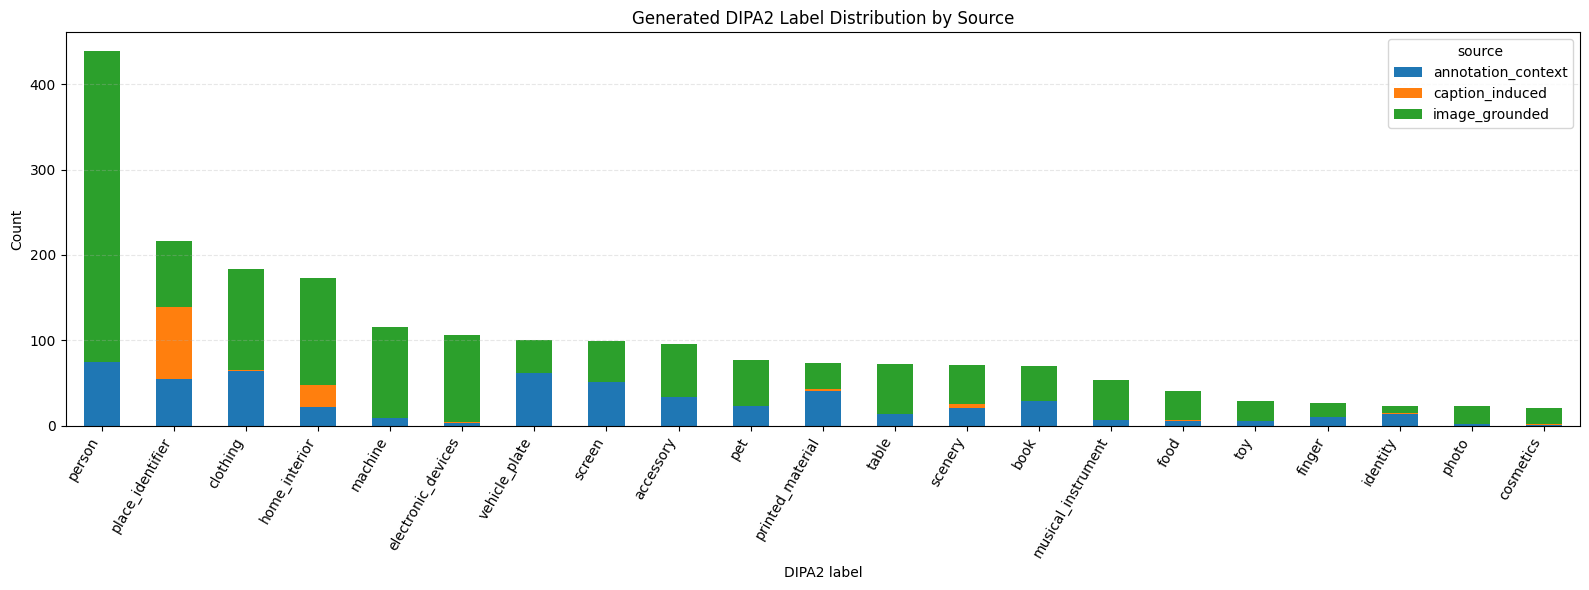

Saved: /content/drive/MyDrive/DIPA2/new_exps/caption_gen_dipa3/graphs/generated_dipa2_label_distribution.png
Saved: /content/drive/MyDrive/DIPA2/new_exps/caption_gen_dipa3/reports/generated_label_counts_by_source.csv


In [ ]:
import matplotlib.pyplot as plt

def plot_generated_label_distribution(df_labels: pd.DataFrame, top_n: int | None = None):
    if df_labels.empty:
        print("No labels found.")
        return pd.DataFrame()

    counts = (
        df_labels
        .groupby(["label", "source"])
        .size()
        .reset_index(name="count")
    )

    pivot = counts.pivot_table(
        index="label",
        columns="source",
        values="count",
        fill_value=0,
        aggfunc="sum",
    )

    pivot["total"] = pivot.sum(axis=1)
    pivot = pivot.sort_values("total", ascending=False)

    if top_n is not None:
        pivot = pivot.head(top_n)

    display(pivot)

    ax = pivot.drop(columns=["total"]).plot(kind="bar", stacked=True, figsize=(16, 6))
    ax.set_title("Generated DIPA2 Label Distribution by Source")
    ax.set_xlabel("DIPA2 label")
    ax.set_ylabel("Count")
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()

    out_path = GRAPH_DIR / "generated_dipa2_label_distribution.png"
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)

    return pivot

generated_label_counts = plot_generated_label_distribution(df_labels)
generated_label_counts.to_csv(REPORT_DIR / "generated_label_counts_by_source.csv")
print("Saved:", REPORT_DIR / "generated_label_counts_by_source.csv")


## 14. Gold DIPA2 distribution vs generated labels

In [ ]:
def make_gold_dipa2_distribution(df: pd.DataFrame):
    # Row-level count: every privacy annotation row.
    row_counts = df["dipa_label"].value_counts().rename_axis("label").reset_index(name="gold_row_count")

    # Image-level count: label appears at least once in an image.
    image_label_pairs = df[["image_name", "dipa_label"]].drop_duplicates()
    image_counts = image_label_pairs["dipa_label"].value_counts().rename_axis("label").reset_index(name="gold_image_count")

    out = row_counts.merge(image_counts, on="label", how="outer").fillna(0)
    out["gold_row_count"] = out["gold_row_count"].astype(int)
    out["gold_image_count"] = out["gold_image_count"].astype(int)
    return out.sort_values("gold_row_count", ascending=False)

gold_dist = make_gold_dipa2_distribution(df_dipa2)
display(gold_dist)

generated_dist_simple = (
    df_labels["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="generated_label_count")
) if not df_labels.empty else pd.DataFrame(columns=["label", "generated_label_count"])

merged_dist = gold_dist.merge(generated_dist_simple, on="label", how="outer").fillna(0)
merged_dist["generated_label_count"] = merged_dist["generated_label_count"].astype(int)
merged_dist = merged_dist.sort_values("gold_row_count", ascending=False)

display(merged_dist)
merged_dist.to_csv(REPORT_DIR / "gold_vs_generated_dipa2_label_distribution.csv", index=False)
print("Saved:", REPORT_DIR / "gold_vs_generated_dipa2_label_distribution.csv")


,label,gold_row_count,gold_image_count
11,others,2711,953
12,person,1819,310
21,vehicle_plate,254,96
18,screen,246,95
2,clothing,184,123
15,place_identifier,109,62
16,printed_material,81,40
0,accessory,80,52
1,book,72,50
13,pet,65,47


,label,gold_row_count,gold_image_count,generated_label_count
11,others,2711,953,0
12,person,1819,310,439
21,vehicle_plate,254,96,100
18,screen,246,95,99
2,clothing,184,123,184
15,place_identifier,109,62,216
16,printed_material,81,40,73
0,accessory,80,52,96
1,book,72,50,70
13,pet,65,47,77


Saved: /content/drive/MyDrive/DIPA2/new_exps/caption_gen_dipa3/reports/gold_vs_generated_dipa2_label_distribution.csv


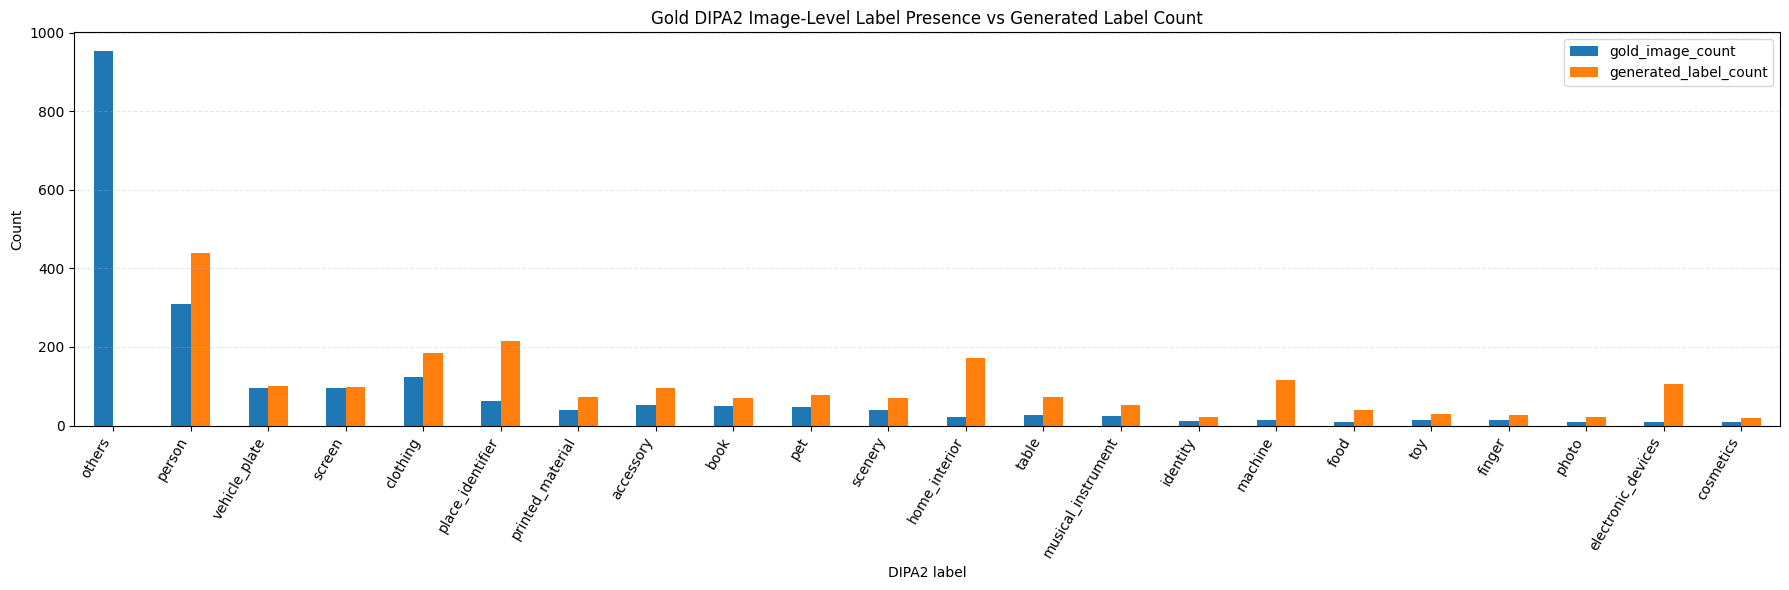

Saved: /content/drive/MyDrive/DIPA2/new_exps/caption_gen_dipa3/graphs/gold_vs_generated_dipa2_distribution.png


In [ ]:
def plot_gold_vs_generated(merged_dist: pd.DataFrame):
    if merged_dist.empty:
        print("Nothing to plot.")
        return

    plot_df = merged_dist.set_index("label")[["gold_image_count", "generated_label_count"]]
    ax = plot_df.plot(kind="bar", figsize=(18, 6))
    ax.set_title("Gold DIPA2 Image-Level Label Presence vs Generated Label Count")
    ax.set_xlabel("DIPA2 label")
    ax.set_ylabel("Count")
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    plt.xticks(rotation=60, ha="right")
    plt.tight_layout()

    out_path = GRAPH_DIR / "gold_vs_generated_dipa2_distribution.png"
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", out_path)

plot_gold_vs_generated(merged_dist)


## 15. Inspect individual outputs

In [ ]:
def show_output(image_id_or_name: str):
    key = Path(image_id_or_name).stem
    jf = OUTPUT_DIR / f"{key}.json"
    if not jf.exists():
        print("Missing:", jf)
        return

    data = json.loads(jf.read_text(encoding="utf-8"))

    print("image:", data.get("image_name"))
    print("explicit:", data.get("captions", {}).get("explicit", ""))
    print("no_leak:", data.get("captions", {}).get("no_leak", ""))
    print("selected:", data.get("selected_labels", {}))
    print("\nlabels:")
    for item in data.get("labels", []):
        print("-", item)

    print("\nDIPA2 kept labels:", (data.get("dipa2_context") or {}).get("kept_labels"))

# Example:
if len(df_images):
    show_output(df_images.iloc[0]["image_id"])


image: 0007cebe1b2ba653.jpg
explicit: My dog is having a blast at our favorite local park; it's the only place he can run off-leash safely since we live in the nearby Oakwood apartments.
no_leak: My dog is having a blast running around at the park today.
selected: {'explicit': ['pet', 'scenery'], 'moderate': None}

labels:
- {'label': 'pet', 'source': 'image_grounded', 'evidence': 'The caption mentions the dog as a personal companion in a daily routine.', 'confidence': 1.0}
- {'label': 'scenery', 'source': 'caption_induced', 'evidence': 'The caption reveals the neighborhood of residence by mentioning a specific local apartment complex.', 'confidence': 0.9}

DIPA2 kept labels: ['pet']


## 16. Optional: visualize image with DIPA2 context

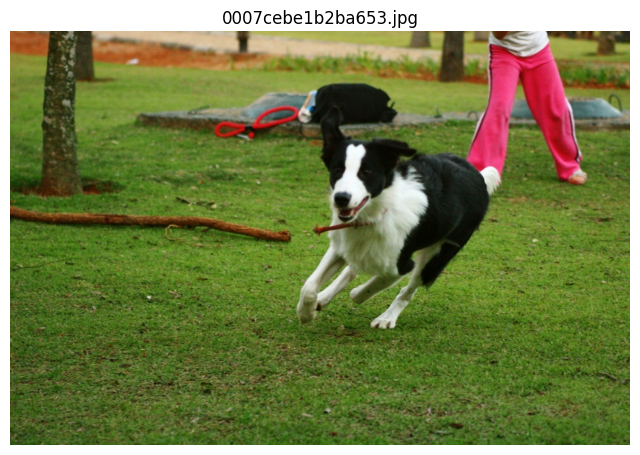

image_name: 0007cebe1b2ba653.jpg
image_id: 0007cebe1b2ba653
privacy_annotation_rows: 3
annotation_files_by_platform: {'CrowdWorks': 2, 'Prolific': 2}
privacy_rows_by_platform: {'CrowdWorks': 3}
kept_labels_after_aggregation: ['pet']

Aggregated DIPA2 category evidence:
- pet (KEEP): row_support=1, platforms=['CrowdWorks'], mean_informativeness=4.0, max_informativeness=4.0
  raw_objects=[('Dog', 1)]
  information_types=[('personal_information', 1), ('location_of_shooting', 1), ('social_circle', 1)]
  sharing_owner=[('close_relationship', 1)]
  sharing_others=[('regular_relationship', 1)]


In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

def show_image_and_context(image_name: str):
    img_path = IMAGE_DIR / image_name
    if not img_path.exists():
        print("Missing image:", img_path)
        return

    img = Image.open(img_path)
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(image_name)
    plt.show()

    print(context_to_prompt_text(dipa2_contexts.get(image_name))[:6000])

# Example:
if images_to_process:
    show_image_and_context(images_to_process[0].name)


## Notes

Recommended workflow:
1. Set `MAX_IMAGES = 5`, run the notebook once, and inspect outputs.
2. If outputs look good, set `MAX_IMAGES = None`.
3. Keep `SKIP_IF_JSON_EXISTS = True` so the run is resumable.
4. For stricter use of multiple annotators, set:
   - `AGGREGATION_MODE = "supported"`
   - `MIN_ROW_SUPPORT = 2`
   - optionally `REQUIRE_BOTH_PLATFORMS = True`
5. If `others` dominates too much, set `DROP_OTHERS = True`.
